# Step 5 — Model Training & Evaluation (GroupKFold, leakage-free)

## 🎯 Objetivo
Treinar e comparar modelos simples (KNN, Decision Tree, Random Forest, SVM) para prever **progressão rápida vs lenta** em:
- **3 meses (90±7)**
- **6 meses (180±7)**

A avaliação é *subject-wise* (GroupKFold) para garantir que o mesmo doente não aparece em treino e teste.

## 📥 Inputs
- `01_data/processed/dataset_3m_v1.csv`
- `01_data/processed/dataset_6m_v1.csv`
*(datasets já com features @t0 + slope por horizonte)*

## 📤 Outputs
- `04_outputs/tables/step5_model_results_v2_thresholded.csv`
- `04_outputs/figures/step5_pr_auc_3m*.png`
- `04_outputs/figures/step5_pr_auc_6m*.png`
- `04_outputs/figures/step5_pr_auc_3m_vs_6m*.png`
- `04_outputs/figures/step5_f2_*.png`
- `04_outputs/figures/step5_fp_fn_*_common.png`

## ⚙️ Parâmetros principais
- Split: **GroupKFold (por doente)**
- Classe positiva: **rapid = top 30% piores slopes** *(definido dentro do treino de cada fold)*
- Threshold: **otimizado por fold para maximizar F2** *(no treino)*

<div style="padding:10px;border-left:6px solid #FF5F5D;">
<b>Nota leakage-free:</b> labels (rapid/slow) e threshold de decisão são estimados apenas no treino de cada fold. O teste é usado exclusivamente para avaliação.
</div>


In [4]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, f1_score, fbeta_score,
    confusion_matrix
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


In [5]:
RAW = os.path.join("..", "01_data")
INTERIM = os.path.join("..", "01_data", "interim")
PROCESSED = os.path.join("..", "01_data", "processed")
OUT_TABLES = os.path.join("..", "04_outputs", "tables")

os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(OUT_TABLES, exist_ok=True)

X_path = os.path.join(PROCESSED, "features_baseline_v1.csv")
T_path = os.path.join(INTERIM, "baseline_with_targets_step3_nolabels.csv")

Xdf = pd.read_csv(X_path)
Tdf = pd.read_csv(T_path)

print("Xdf:", Xdf.shape)
print("Tdf:", Tdf.shape)


Xdf: (5436, 35)
Tdf: (5436, 28)


## 1) Preparar datasets finais (3m e 6m)

Nesta secção:
- carregamos as tabelas de features (baseline/vitals/resp)
- juntamos com os slopes por horizonte
- garantimos **1 linha por doente**
- isolamos dois datasets finais:
  - `dataset_3m_v1` (slope 90d disponível)
  - `dataset_6m_v1` (slope 180d disponível)

<b>Objetivo prático:</b> garantir que o treino usa apenas features @t0 e o target vem do período futuro (t0→t0+H).


In [6]:
df = Xdf.merge(
    Tdf[["subject_id", "slope_90d_per_30d", "slope_180d_per_30d"]],
    on="subject_id", how="inner"
)

df3 = df[df["slope_90d_per_30d"].notna()].copy()
df6 = df[df["slope_180d_per_30d"].notna()].copy()

print("Dataset 3m:", df3.shape, "| N subjects:", df3["subject_id"].nunique())
print("Dataset 6m:", df6.shape, "| N subjects:", df6["subject_id"].nunique())


Dataset 3m: (2407, 37) | N subjects: 2407
Dataset 6m: (1392, 37) | N subjects: 1392


## 1.1) Guardar datasets prontos para treino (reprodutibilidade)

Guardamos versões “congeladas” dos datasets 3m e 6m para:
- reproduzir resultados (sem depender de reprocessar tudo)
- permitir auditoria de colunas/linhas
- simplificar o Step 6 (XAI)

<b>Regra:</b> estes ficheiros não devem ser alterados manualmente; qualquer mudança deve vir do pipeline (Step 4).


In [7]:
df3.to_csv(os.path.join(PROCESSED, "dataset_3m_v1.csv"), index=False)
df6.to_csv(os.path.join(PROCESSED, "dataset_6m_v1.csv"), index=False)


## 2) Definir X (features) e y-base (slope)

Aqui escolhemos:
- **X:** colunas preditoras (apenas baseline/t0)
- **slope:** variável contínua usada para criar o binário rapid/slow por fold
- **groups:** identificador do doente (para GroupKFold)

<b>Nota:</b> não fixamos “y binário” global aqui. O rótulo rapid/slow é criado dentro de cada fold a partir do slope do treino (top 30%).


In [8]:
DROP_ALWAYS = {
    "subject_id",
    "slope_90d_per_30d", "slope_180d_per_30d",
    "slope_90d_per_day", "slope_180d_per_day",
    "npoints_90d_window", "npoints_180d_window",
    "has_endband_90d", "has_endband_180d",
    "pref_ok_90d_min3", "pref_ok_180d_min3",
}

def split_X_y(df_in, slope_col):
    cols = [c for c in df_in.columns if c not in DROP_ALWAYS]
    X = df_in[cols].copy()
    slope = df_in[slope_col].copy()
    groups = df_in["subject_id"].copy()
    return X, slope, groups

X3, slope3, g3 = split_X_y(df3, "slope_90d_per_30d")
X6, slope6, g6 = split_X_y(df6, "slope_180d_per_30d")

print("X3:", X3.shape, "| X6:", X6.shape)


X3: (2407, 34) | X6: (1392, 34)


## 3) Pré-processamento (numérico + categórico)

Objetivo: preparar dados de forma consistente para modelos diferentes.

- Numéricos: imputação (mediana) + (opcional) escala
- Categóricos: imputação (mais frequente) + one-hot encoding
- Modelos sensíveis à escala (KNN, SVM): usam pipeline com scaler
- Modelos de árvore (DecisionTree, RandomForest): não precisam de escala

<b>Porque isto importa:</b> evita falhas por strings (“Male”) e reduz viés de missingness.


In [9]:
from sklearn.preprocessing import OneHotEncoder

# detectar colunas por tipo
num_cols_3 = X3.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_3 = [c for c in X3.columns if c not in num_cols_3]

num_cols_6 = X6.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_6 = [c for c in X6.columns if c not in num_cols_6]

print("3m -> num:", len(num_cols_3), "cat:", len(cat_cols_3))
print("6m -> num:", len(num_cols_6), "cat:", len(cat_cols_6))
print("Exemplo cat 3m:", cat_cols_3[:10])

num_preprocess_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

num_preprocess_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

cat_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])



3m -> num: 30 cat: 4
6m -> num: 30 cat: 4
Exemplo cat 3m: ['Sex', 'Ethnicity', 'Mode_of_Administration', 'ALSFRS_Responded_By']


## 3.1) ColumnTransformer (pipeline reproduzível)

Usamos ColumnTransformer para aplicar transformações diferentes por tipo de variável:
- colunas numéricas → imputação/escala
- colunas categóricas → imputação/one-hot

<b>Vantagem:</b> o mesmo pipeline serve treino, teste e exportação do modelo final.


In [10]:
from sklearn.compose import ColumnTransformer

# Preprocessadores para modelos que precisam de scaling (KNN, SVM)
preproc_scaled_3 = ColumnTransformer(
    transformers=[
        ("num", num_preprocess_scaled, num_cols_3),
        ("cat", cat_preprocess, cat_cols_3),
    ],
    remainder="drop"
)

preproc_scaled_6 = ColumnTransformer(
    transformers=[
        ("num", num_preprocess_scaled, num_cols_6),
        ("cat", cat_preprocess, cat_cols_6),
    ],
    remainder="drop"
)

# Preprocessadores para árvores (DT, RF) (sem scaler)
preproc_tree_3 = ColumnTransformer(
    transformers=[
        ("num", num_preprocess_tree, num_cols_3),
        ("cat", cat_preprocess, cat_cols_3),
    ],
    remainder="drop"
)

preproc_tree_6 = ColumnTransformer(
    transformers=[
        ("num", num_preprocess_tree, num_cols_6),
        ("cat", cat_preprocess, cat_cols_6),
    ],
    remainder="drop"
)


## 4) Função auxiliar: seleção do threshold (max F2)

Em vez de usar threshold fixo (0.5), selecionamos um threshold que maximiza **F2** no treino do fold.

<b>Motivação:</b> o problema é desbalanceado e, clinicamente, penalizamos mais falhar “rapid” (FN) do que gerar falsos alarmes (FP).


In [11]:
import numpy as np
from sklearn.metrics import fbeta_score

def pick_threshold_max_fbeta(y_true, proba, beta=2, grid=None):
    """
    Escolhe threshold que maximiza F-beta no conjunto (y_true, proba).
    grid: lista/array de thresholds a testar.
    """
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)

    best_t = 0.5
    best_s = -1.0

    for t in grid:
        yhat = (proba >= t).astype(int)
        s = fbeta_score(y_true, yhat, beta=beta, zero_division=0)
        if s > best_s:
            best_s = s
            best_t = float(t)

    return best_t, float(best_s)


## 5) Avaliação leakage-free com GroupKFold (labels e threshold por fold)

Para cada modelo e para cada fold:
1) split subject-wise (GroupKFold)
2) no treino: calcular `thr_label` = percentil 30% do slope (piores declínios)
3) criar y binário (rapid = slope ≤ thr_label)
4) treinar modelo
5) no treino: escolher `thr_decision` que maximiza F2
6) no teste: avaliar PR-AUC (threshold-free) e F2/F1 + FP/FN (thresholded)

<b>Output:</b> métricas médias e desvio padrão por modelo e por horizonte.


In [12]:
from sklearn.metrics import average_precision_score, f1_score, fbeta_score, confusion_matrix

def evaluate_models(X, slope, groups, horizon_name, preproc_scaled, preproc_tree,
                    top_frac=0.30, n_splits=5, random_state=42,
                    beta=2, thr_grid=None):

    gkf = GroupKFold(n_splits=n_splits)

    models = [
        ("KNN", Pipeline(steps=[
            ("prep", preproc_scaled),
            ("clf", KNeighborsClassifier(n_neighbors=15))
        ])),
        ("DecisionTree", Pipeline(steps=[
            ("prep", preproc_tree),
            ("clf", DecisionTreeClassifier(max_depth=5, random_state=random_state))
        ])),
        ("RandomForest", Pipeline(steps=[
            ("prep", preproc_tree),
            ("clf", RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                min_samples_leaf=2,
                random_state=random_state,
                n_jobs=-1
            ))
        ])),
        ("SVM", Pipeline(steps=[
            ("prep", preproc_scaled),
            ("clf", SVC(
                C=1.0, kernel="rbf",
                probability=True,
                class_weight="balanced",
                random_state=random_state
            ))
        ])),
    ]

    rows = []
    for name, pipe in models:
        pr_list, f1_list, f2_list = [], [], []
        tn_list, fp_list, fn_list, tp_list = [], [], [], []
        thr_list = []

        for fold, (tr, te) in enumerate(gkf.split(X, groups=groups), start=1):
            Xtr, Xte = X.iloc[tr], X.iloc[te]
            slope_tr, slope_te = slope.iloc[tr], slope.iloc[te]

            # 1) label threshold (top 30% mais negativos) calculado só no treino
            thr_label = np.nanquantile(slope_tr.dropna(), top_frac)
            ytr = (slope_tr <= thr_label).astype(int)
            yte = (slope_te <= thr_label).astype(int)

            # 2) treinar
            pipe.fit(Xtr, ytr)

            # 3) escolher threshold de decisão no treino (max F-beta)
            proba_tr = pipe.predict_proba(Xtr)[:, 1]
            thr_decision, _ = pick_threshold_max_fbeta(ytr.to_numpy(), proba_tr, beta=beta, grid=thr_grid)
            thr_list.append(thr_decision)

            # 4) avaliar no teste com esse threshold
            proba_te = pipe.predict_proba(Xte)[:, 1]
            yhat = (proba_te >= thr_decision).astype(int)

            pr = average_precision_score(yte, proba_te)
            f1 = f1_score(yte, yhat, zero_division=0)
            f2 = fbeta_score(yte, yhat, beta=beta, zero_division=0)

            tn, fp, fn, tp = confusion_matrix(yte, yhat, labels=[0, 1]).ravel()

            pr_list.append(pr); f1_list.append(f1); f2_list.append(f2)
            tn_list.append(tn); fp_list.append(fp); fn_list.append(fn); tp_list.append(tp)

        rows.append({
            "horizon": horizon_name,
            "model": name,

            "PR_AUC_mean": float(np.mean(pr_list)),
            "PR_AUC_std": float(np.std(pr_list)),

            "F1_mean": float(np.mean(f1_list)),
            "F1_std": float(np.std(f1_list)),

            f"F{beta}_mean": float(np.mean(f2_list)),
            f"F{beta}_std": float(np.std(f2_list)),

            "TN_mean": float(np.mean(tn_list)),
            "FP_mean": float(np.mean(fp_list)),
            "FN_mean": float(np.mean(fn_list)),
            "TP_mean": float(np.mean(tp_list)),

            "thr_decision_mean": float(np.mean(thr_list)),
            "thr_decision_std": float(np.std(thr_list)),
        })

    return pd.DataFrame(rows)


## 6) Executar treino/eval (3m e 6m) e guardar resultados

Nesta secção:
- corremos a avaliação para 3m e 6m
- juntamos numa tabela única
- guardamos CSV final “tese-ready” com:
  - PR-AUC_mean/std
  - F1_mean/std
  - F2_mean/std
  - FP/FN/TP/TN (médias)
  - threshold médio de decisão (thr_decision_mean/std)


In [13]:
res3 = evaluate_models(
    X3, slope3, g3,
    horizon_name="3m",
    preproc_scaled=preproc_scaled_3,
    preproc_tree=preproc_tree_3,
    top_frac=0.30,
    n_splits=5,
    beta=2
)

res6 = evaluate_models(
    X6, slope6, g6,
    horizon_name="6m",
    preproc_scaled=preproc_scaled_6,
    preproc_tree=preproc_tree_6,
    top_frac=0.30,
    n_splits=5,
    beta=2
)

results = pd.concat([res3, res6], ignore_index=True)
results = results.sort_values(["horizon", "PR_AUC_mean"], ascending=[True, False])

out = os.path.join(OUT_TABLES, "step5_model_results_v2_thresholded.csv")
results.to_csv(out, index=False)

print("Guardado:", out)
results


Guardado: ..\04_outputs\tables\step5_model_results_v2_thresholded.csv


,horizon,model,PR_AUC_mean,PR_AUC_std,F1_mean,F1_std,F2_mean,F2_std,TN_mean,FP_mean,FN_mean,TP_mean,thr_decision_mean,thr_decision_std
2,3m,RandomForest,0.375277,0.033640,0.413758,0.020919,0.450618,0.050175,213.6,122.0,75.6,70.2,0.33,0.024495
3,3m,SVM,0.364767,0.027834,0.470047,0.028264,0.636563,0.033561,85.6,250.0,24.0,121.8,0.25,0.000000
1,3m,DecisionTree,0.358540,0.036047,0.460942,0.022259,0.658459,0.018166,32.4,303.2,11.2,134.6,0.11,0.020000
0,3m,KNN,0.336942,0.030335,0.461340,0.025318,0.661887,0.032544,28.2,307.4,9.6,136.2,0.11,0.020000
7,6m,SVM,0.414241,0.069091,0.462180,0.053396,0.611711,0.053058,60.4,134.6,17.6,65.8,0.24,0.020000
6,6m,RandomForest,0.396878,0.052880,0.417542,0.041561,0.435030,0.036248,137.4,57.6,46.2,37.2,0.35,0.000000
5,6m,DecisionTree,0.369077,0.062443,0.453262,0.056252,0.632616,0.068168,34.2,160.8,10.8,72.6,0.13,0.040000
4,6m,KNN,0.347120,0.039424,0.457772,0.049637,0.634402,0.038161,36.8,158.2,11.6,71.8,0.17,0.040000


## 7) Visualização rápida (sanity check)

Antes de produzir figuras finais, fazemos um gráfico simples para confirmar:
- ordenação dos modelos
- valores dentro de gamas plausíveis
- ausência de comportamento degenerado (ex.: F2=0 por prever sempre 0)

<b>Nota:</b> as figuras finais vêm nas secções seguintes.


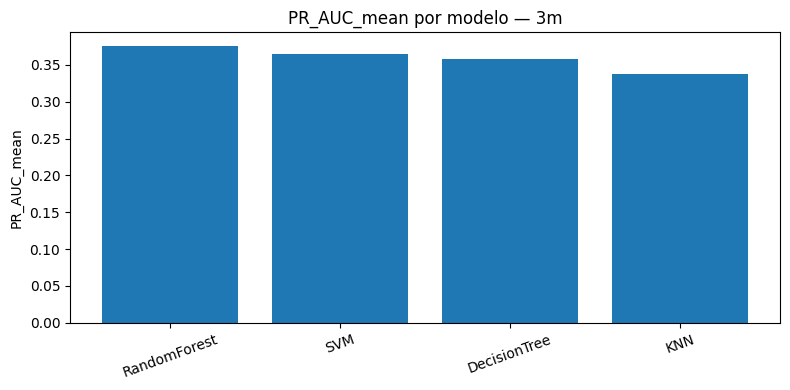

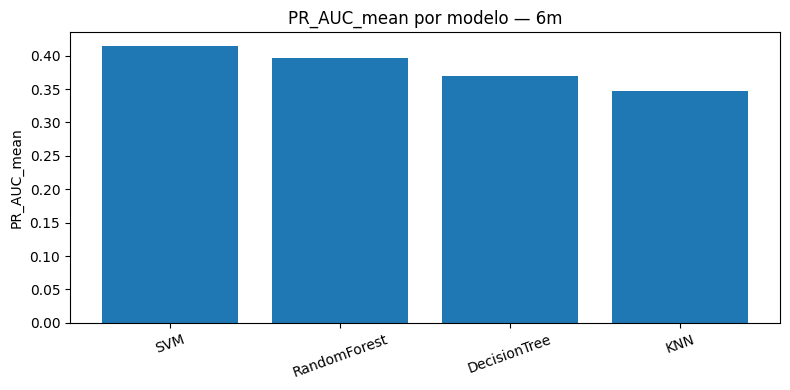

In [14]:
import matplotlib.pyplot as plt

def barplot_metric(df, horizon, metric):
    sub = df[df["horizon"] == horizon].sort_values(metric, ascending=False)
    plt.figure(figsize=(8,4))
    plt.bar(sub["model"], sub[metric])
    plt.title(f"{metric} por modelo — {horizon}")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

barplot_metric(results, "3m", "PR_AUC_mean")
barplot_metric(results, "6m", "PR_AUC_mean")


## 8) Figuras finais: PR-AUC (escala comum + erro + baseline)

Geramos gráficos “tese-ready”:
- PR-AUC por modelo (3m e 6m, separados)
- mesma escala Y para comparabilidade
- barras com erro (std por fold)
- linha baseline = 0.30 (prevalência do rapid)

As anotações “+0.XX” representam ganho absoluto sobre o baseline: PR-AUC − 0.30.


In [15]:
import numpy as np
import matplotlib.pyplot as plt

def plot_metric_bars(results_sub, metric_mean, metric_std, title,
                     outfile=None, y_min=None, y_max=None,
                     baseline=None, note=None,
                     bar_color="#50eb79", baseline_color="#0a0807"):

    df = results_sub.copy().sort_values(metric_mean, ascending=False)

    x = np.arange(len(df))
    y = df[metric_mean].to_numpy()
    yerr = df[metric_std].to_numpy()

    plt.figure(figsize=(9,4.5))
    plt.bar(x, y, yerr=yerr, capsize=5, color=bar_color)

    plt.xticks(x, df["model"], rotation=15)
    plt.ylabel(metric_mean.replace("_mean",""))
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.25)

    # ---- limites Y: auto se None ----
    top = float(np.max(y + yerr))
    bot = float(np.min(y - yerr))

    if y_min is None:
        y_min = max(0.0, bot - 0.05)
    if y_max is None:
        y_max = min(1.0, top + 0.05)

    plt.ylim(y_min, y_max)

    if baseline is not None:
        plt.axhline(baseline, linestyle="--", linewidth=2, color=baseline_color,
                    label=f"baseline={baseline:.2f}")

        # texto acima das barras (usa o erro para não colidir)
        for i, (val, err) in enumerate(zip(y, yerr)):
            delta = val - baseline
            plt.text(i, val + err + 0.01, f"{delta:+.02f} acima do baseline",
                     ha="center", va="bottom", fontsize=9)

        plt.legend(loc="lower right")

    if note:
        plt.text(0.01, 0.98, note, transform=plt.gca().transAxes,
                 va="top", ha="left", fontsize=9)

    plt.tight_layout()

    if outfile:
        plt.savefig(outfile, dpi=300)
    plt.show()


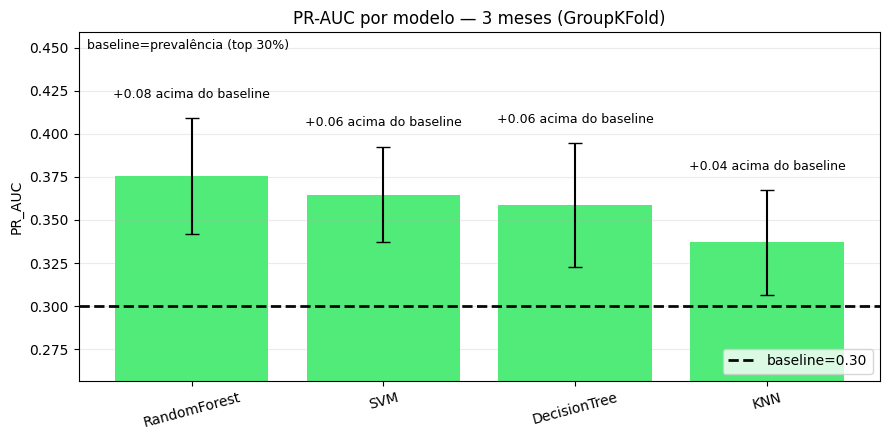

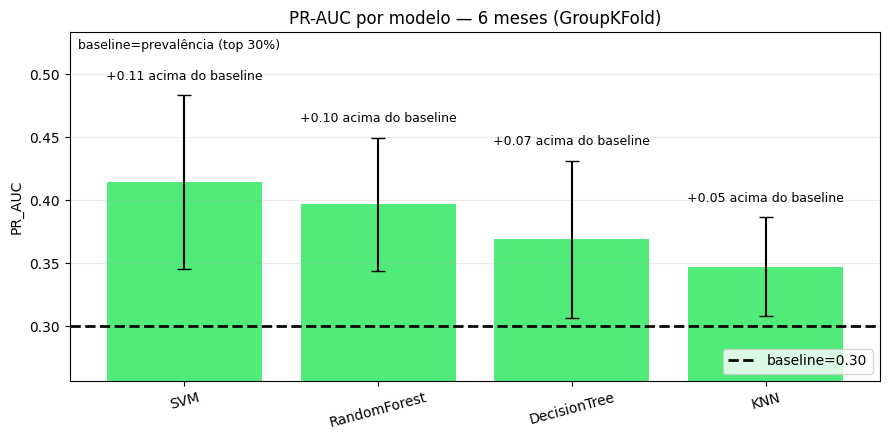

In [16]:
OUT_FIGURES = os.path.join("..", "04_outputs", "figures")
os.makedirs(OUT_FIGURES, exist_ok=True)
res3_sub = results[results["horizon"]=="3m"]
res6_sub = results[results["horizon"]=="6m"]

plot_metric_bars(
    res3_sub, "PR_AUC_mean", "PR_AUC_std",
    "PR-AUC por modelo — 3 meses (GroupKFold)",
    outfile=os.path.join(OUT_FIGURES, "step5_pr_auc_3m_pretty.png"),
    baseline=0.30,
    note="baseline=prevalência (top 30%)"
)

plot_metric_bars(
    res6_sub, "PR_AUC_mean", "PR_AUC_std",
    "PR-AUC por modelo — 6 meses (GroupKFold)",
    outfile=os.path.join(OUT_FIGURES, "step5_pr_auc_6m_pretty.png"),
    baseline=0.30,
    note="baseline=prevalência (top 30%)"
)


## 8.1) PR-AUC 3m vs 6m (figura combinada)

Nesta figura colocamos 3m e 6m lado a lado por modelo para:
- comparar diretamente o impacto do horizonte temporal
- ver se a hierarquia dos modelos é estável
- manter baseline e incerteza (std)

<b>Nota:</b> anotações por barra mostram ganho sobre baseline.


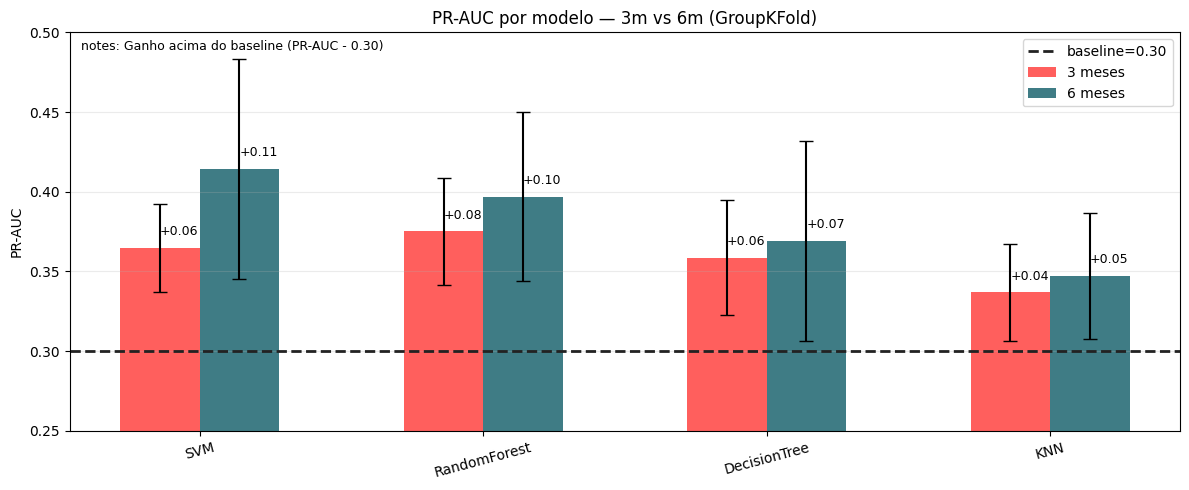

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def pr_auc_grouped_with_gain(results, outfile=None, baseline=0.30,
                             color_3m="#FF5F5D", color_6m="#3F7C85",
                             y_min=0.25, y_max=0.50):

    r3 = results[results["horizon"] == "3m"].set_index("model")
    r6 = results[results["horizon"] == "6m"].set_index("model")

    # ordem fixa por 6m
    order = r6["PR_AUC_mean"].sort_values(ascending=False).index.tolist()
    r3 = r3.loc[order]
    r6 = r6.loc[order]

    x = np.arange(len(order))
    w = 0.28

    plt.figure(figsize=(12, 5))

    bars3 = plt.bar(
        x - w/2, r3["PR_AUC_mean"], yerr=r3["PR_AUC_std"],
        capsize=5, width=w, label="3 meses", color=color_3m
    )
    bars6 = plt.bar(
        x + w/2, r6["PR_AUC_mean"], yerr=r6["PR_AUC_std"],
        capsize=5, width=w, label="6 meses", color=color_6m
    )

    plt.axhline(baseline, linestyle="--", linewidth=2, color="#222222",
                label=f"baseline={baseline:.2f}")

    plt.xticks(x, order, rotation=15)
    plt.ylabel("PR-AUC")
    plt.title("PR-AUC por modelo — 3m vs 6m (GroupKFold)")
    plt.ylim(y_min, y_max)
    plt.grid(True, axis="y", alpha=0.25)

    # ---- ganhos (acima do baseline) em cima de cada barra ----
    def annotate_gain(bar_container, means):
        for rect, val in zip(bar_container, means):
            gain = val - baseline
            y_text = rect.get_height() + 0.006
            plt.text(
                rect.get_x() + rect.get_width()/2,
                y_text,
                f"{gain:+.02f}",
                ha="left", va="bottom", fontsize=9
            )

    annotate_gain(bars3, r3["PR_AUC_mean"].to_numpy())
    annotate_gain(bars6, r6["PR_AUC_mean"].to_numpy())

    # nota fixa (para não repetir "acima do baseline" 8 vezes)
    plt.text(
        0.01, 0.98,
        "notes: Ganho acima do baseline (PR-AUC - 0.30)",
        transform=plt.gca().transAxes,
        ha="left", va="top", fontsize=9
    )

    plt.legend(loc="upper right")
    plt.tight_layout()

    if outfile:
        plt.savefig(outfile, dpi=300)
    plt.show()

pr_auc_grouped_with_gain(
    results,
    outfile=os.path.join(OUT_FIGURES, "step5_pr_auc_3m_vs_6m_gain.png"),
    baseline=0.30
)


## 9) Figuras finais: F2 e trade-off FP vs FN

- F2 por modelo (3m e 6m), com threshold otimizado por fold.
- Gráfico FP vs FN (escala comum), para tornar explícito o custo operacional:
  - FN: rapids falhados
  - FP: falsos alarmes

<b>Interpretação esperada:</b> modelos mais “agressivos” aumentam F2 reduzindo FN, mas à custa de FP mais alto.


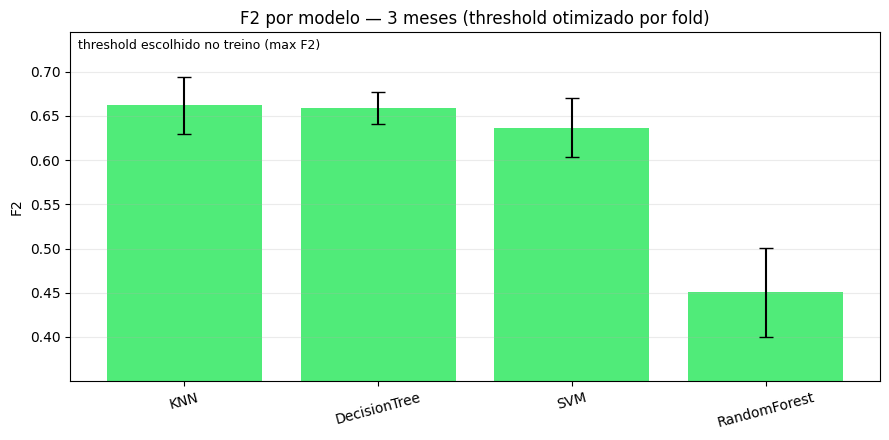

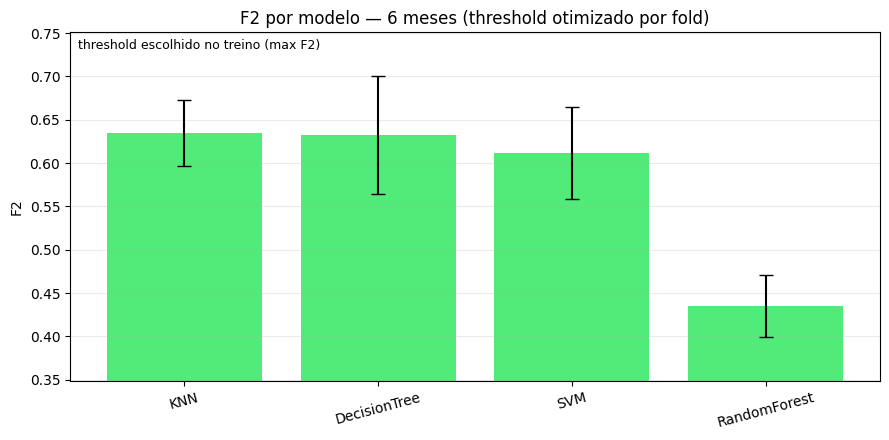

In [18]:
res3_sub = results[results["horizon"]=="3m"]
res6_sub = results[results["horizon"]=="6m"]

plot_metric_bars(
    res3_sub, "F2_mean", "F2_std",
    "F2 por modelo — 3 meses (threshold otimizado por fold)",
    outfile=os.path.join(OUT_FIGURES, "step5_f2_3m.png"),
    baseline=None,
    note="threshold escolhido no treino (max F2)"
)

plot_metric_bars(
    res6_sub, "F2_mean", "F2_std",
    "F2 por modelo — 6 meses (threshold otimizado por fold)",
    outfile=os.path.join(OUT_FIGURES, "step5_f2_6m.png"),
    baseline=None,
    note="threshold escolhido no treino (max F2)"
)


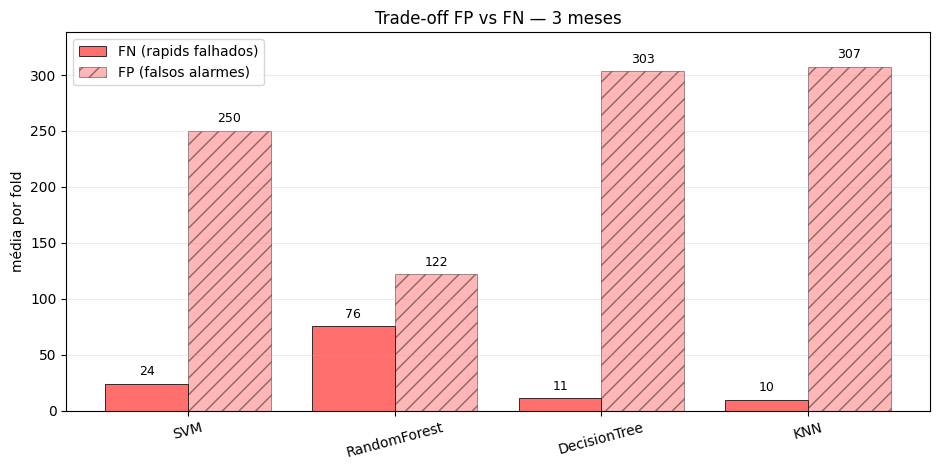

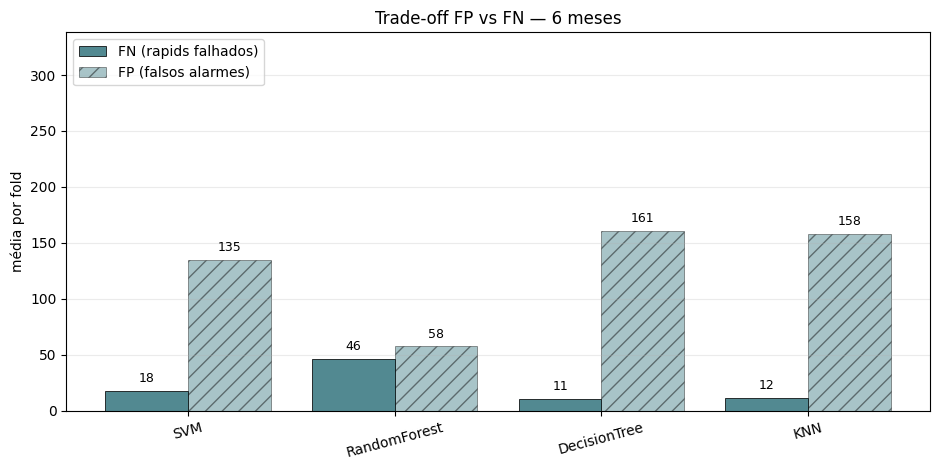

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fp_fn(results_sub, title, outfile=None,
               ylim_top=None, base_color="#FF5F5D",
               show_values=True):

    order = ["SVM", "RandomForest", "DecisionTree", "KNN"]
    df = results_sub.copy().set_index("model").loc[order]

    x = np.arange(len(df))
    w = 0.40

    # cores dentro do horizonte
    color_fn = base_color
    color_fp = base_color

    plt.figure(figsize=(9.5, 4.8))

    b_fn = plt.bar(
        x - w/2, df["FN_mean"], width=w,
        label="FN (rapids falhados)",
        color=color_fn, alpha=0.90, edgecolor="black", linewidth=0.6
    )
    b_fp = plt.bar(
        x + w/2, df["FP_mean"], width=w,
        label="FP (falsos alarmes)",
        color=color_fp, alpha=0.45, edgecolor="black", linewidth=0.6, hatch="//"
    )

    plt.xticks(x, df.index, rotation=15)
    plt.ylabel("média por fold")
    plt.title(title)

    # escala comum (se fornecida)
    if ylim_top is not None:
        plt.ylim(0, ylim_top)

    plt.grid(True, axis="y", alpha=0.25)

    # valores em cima das barras (opcional, mas ajuda)
    if show_values:
        for bars in (b_fn, b_fp):
            for r in bars:
                h = r.get_height()
                plt.text(
                    r.get_x() + r.get_width()/2,
                    h + (ylim_top*0.015 if ylim_top else 2),
                    f"{h:.0f}",
                    ha="center", va="bottom", fontsize=9
                )

    plt.legend(loc="upper left")
    plt.tight_layout()

    if outfile:
        plt.savefig(outfile, dpi=300)
    plt.show()


# --- calcular máximo global para escala comum ---
def compute_common_ylim(results_3m, results_6m, pad=1.10):
    vals = []
    for r in (results_3m, results_6m):
        vals.extend(r["FN_mean"].tolist())
        vals.extend(r["FP_mean"].tolist())
    m = max(vals) if vals else 1
    return m * pad


# uso:
ylim_common = compute_common_ylim(res3_sub, res6_sub, pad=1.10)

plot_fp_fn(
    res3_sub,
    "Trade-off FP vs FN — 3 meses",
    outfile=os.path.join(OUT_FIGURES, "step5_fp_fn_3m_common.png"),
    ylim_top=ylim_common,
    base_color="#FF5F5D"
)

plot_fp_fn(
    res6_sub,
    "Trade-off FP vs FN — 6 meses",
    outfile=os.path.join(OUT_FIGURES, "step5_fp_fn_6m_common.png"),
    ylim_top=ylim_common,
    base_color="#3F7C85"
)


## ✅ Takeaways (para a tese)

- PR-AUC compara modelos de forma robusta (independente do threshold).
- Threshold otimizado por fold (max F2) define um ponto de operação alinhado com alta sensibilidade.
- O trade-off FP/FN distingue claramente modelos agressivos vs conservadores.
- Os resultados são leakage-free: splits por doente + labels/threshold definidos no treino.


# Step 5.1 — Ablation Study (SVM vs RandomForest) — Feature Blocks

## 🎯 Objetivo
Medir **de onde vem o sinal preditivo** ao comparar blocos de features, mantendo:
- o mesmo protocolo leakage-free (GroupKFold subject-wise)
- labels rapid/slow definidos por fold (top 30% piores slopes no treino)
- threshold otimizado por fold (max F2 no treino)

## Modelos (fixos neste step)
- SVM
- RandomForest

## Blocos de features avaliados
A) Baseline-only  
B) Baseline + Vitals  
C) Baseline + FVC  
D) Baseline + Vitals + FVC

## Resultados esperados
- Tabela com PR-AUC e F2 (média ± std) por horizonte e bloco
- Figura principal: **dumbbell plot** do ganho incremental por bloco (mais claro do que barras)
- (Opcional) heatmap para vista global


In [20]:
# --- Step 5.1: definir blocos de features (heurístico por nome de coluna) ---

def infer_feature_blocks(X):
    cols = list(X.columns)

    # tenta detetar blocos por padrões comuns
    vitals_cols = [c for c in cols if ("vital" in c.lower()) or (c.lower().endswith("_t0") and any(k in c.lower() for k in ["weight","height","bmi","bp","pulse","temp","resp","hr"]))]
    fvc_cols    = [c for c in cols if "fvc" in c.lower()]
    
    # baseline = tudo o que não é vitals nem fvc
    baseline_cols = [c for c in cols if (c not in vitals_cols) and (c not in fvc_cols)]

    blocks = {
        "A_baseline": baseline_cols,
        "B_baseline+vitals": sorted(set(baseline_cols + vitals_cols)),
        "C_baseline+fvc": sorted(set(baseline_cols + fvc_cols)),
        "D_baseline+vitals+fvc": sorted(set(baseline_cols + vitals_cols + fvc_cols)),
    }
    # limpeza: remover duplicados e garantir não vazio
    blocks = {k: [c for c in v if c in cols] for k, v in blocks.items()}
    return blocks, vitals_cols, fvc_cols, baseline_cols

blocks3, vitals3, fvc3, base3 = infer_feature_blocks(X3)
blocks6, vitals6, fvc6, base6 = infer_feature_blocks(X6)

print("3m | baseline:", len(base3), "vitals:", len(vitals3), "fvc:", len(fvc3))
print("6m | baseline:", len(base6), "vitals:", len(vitals6), "fvc:", len(fvc6))

# sanity check: garantir que os blocos têm colunas
for name, cols_ in blocks3.items():
    print("3m", name, "->", len(cols_))
for name, cols_ in blocks6.items():
    print("6m", name, "->", len(cols_))


3m | baseline: 27 vitals: 4 fvc: 3
6m | baseline: 27 vitals: 4 fvc: 3
3m A_baseline -> 27
3m B_baseline+vitals -> 31
3m C_baseline+fvc -> 30
3m D_baseline+vitals+fvc -> 34
6m A_baseline -> 27
6m B_baseline+vitals -> 31
6m C_baseline+fvc -> 30
6m D_baseline+vitals+fvc -> 34


## 5.1.1) Executar ablation (SVM e RandomForest) por bloco

Para cada horizonte (3m e 6m) avaliamos os 4 blocos A–D.  
O protocolo mantém-se exatamente igual ao Step 5:
- labels rapid/slow definidos por fold (top 30% piores slopes no treino)
- threshold de decisão escolhido por fold para maximizar F2 no treino
- avaliação em teste por fold, com média ± std


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def build_preprocessors_for_X(X):
    # colunas numéricas/categóricas a partir do dataframe atual
    num_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    num_pipe_scaled = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    num_pipe_tree = Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preproc_scaled = ColumnTransformer(
        transformers=[
            ("num", num_pipe_scaled, num_cols),
            ("cat", cat_pipe, cat_cols)
        ],
        remainder="drop"
    )

    preproc_tree = ColumnTransformer(
        transformers=[
            ("num", num_pipe_tree, num_cols),
            ("cat", cat_pipe, cat_cols)
        ],
        remainder="drop"
    )

    return preproc_scaled, preproc_tree, num_cols, cat_cols


In [22]:
# --- Step 5.1: correr ablation por blocos ---

ABL_MODELS = ["SVM", "RandomForest"]

def run_ablation(X, slope, groups, blocks, horizon_name,
                 top_frac=0.30, n_splits=5):

    rows = []
    for block_name, cols_ in blocks.items():
        Xb = X[cols_].copy()

        preproc_scaled_b, preproc_tree_b, num_cols, cat_cols = build_preprocessors_for_X(Xb)

        res = evaluate_models(
            Xb, slope, groups,
            horizon_name=horizon_name,
            preproc_scaled=preproc_scaled_b,
            preproc_tree=preproc_tree_b,
            top_frac=top_frac,
            n_splits=n_splits
        )

        res = res[res["model"].isin(ABL_MODELS)].copy()
        res["feature_block"] = block_name
        res["n_features"] = len(cols_)
        res["n_num"] = len(num_cols)
        res["n_cat"] = len(cat_cols)
        rows.append(res)

    return pd.concat(rows, ignore_index=True)




abl3 = run_ablation(X3, slope3, g3, blocks3, horizon_name="3m", top_frac=0.30, n_splits=5)
abl6 = run_ablation(X6, slope6, g6, blocks6, horizon_name="6m", top_frac=0.30, n_splits=5)

ablation_results = pd.concat([abl3, abl6], ignore_index=True)
ablation_results[["horizon","feature_block","model","n_features","PR_AUC_mean","F2_mean"]].head(12)




,horizon,feature_block,model,n_features,PR_AUC_mean,F2_mean
0,3m,A_baseline,RandomForest,27,0.345950,0.497574
1,3m,A_baseline,SVM,27,0.356817,0.636668
2,3m,B_baseline+vitals,RandomForest,31,0.354682,0.476536
3,3m,B_baseline+vitals,SVM,31,0.353303,0.636325
4,3m,C_baseline+fvc,RandomForest,30,0.376525,0.471005
5,3m,C_baseline+fvc,SVM,30,0.366502,0.627776
6,3m,D_baseline+vitals+fvc,RandomForest,34,0.383271,0.443010
7,3m,D_baseline+vitals+fvc,SVM,34,0.364767,0.636563
8,6m,A_baseline,RandomForest,27,0.383227,0.454906
9,6m,A_baseline,SVM,27,0.410595,0.608873


## 5.1.2) Guardar resultados (tese-ready)

Guardamos uma tabela única com métricas por:
- horizonte (3m/6m)
- modelo (SVM/RF)
- bloco de features (A–D)


In [23]:
out_csv = os.path.join(OUT_TABLES, "step5_1_ablation_svm_rf_fvc.csv")
ablation_results.to_csv(out_csv, index=False)
print("Guardado:", out_csv)


Guardado: ..\04_outputs\tables\step5_1_ablation_svm_rf_fvc.csv


## 5.1.3) Figura principal: evolução por bloco (dumbbell plot)

O dumbbell plot liga o desempenho entre blocos, permitindo ver:
- ganho incremental (baseline → +vitals → +FVC → +both)
- diferenças entre SVM e RF
- comparação 3m vs 6m de forma limpa


Guardado: ..\04_outputs\figures\step5_1_ablation_dumbbell_pr_auc_3m.png


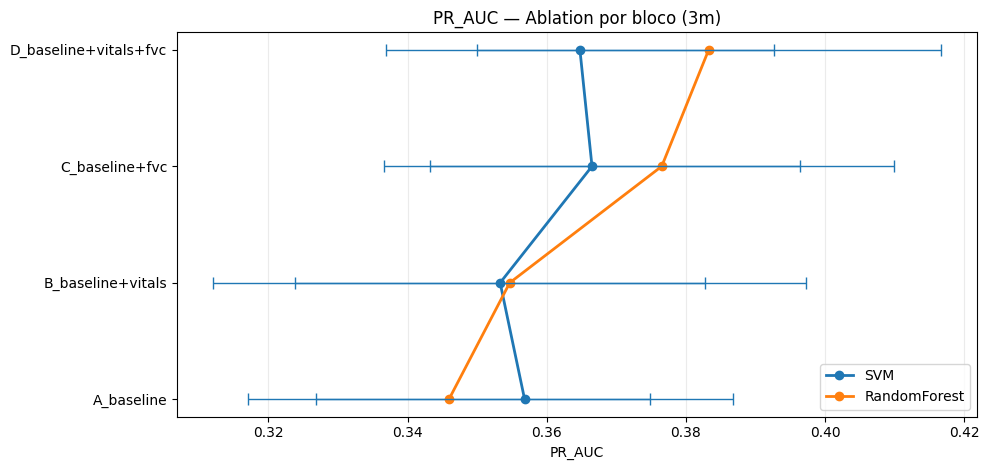

Guardado: ..\04_outputs\figures\step5_1_ablation_dumbbell_pr_auc_6m.png


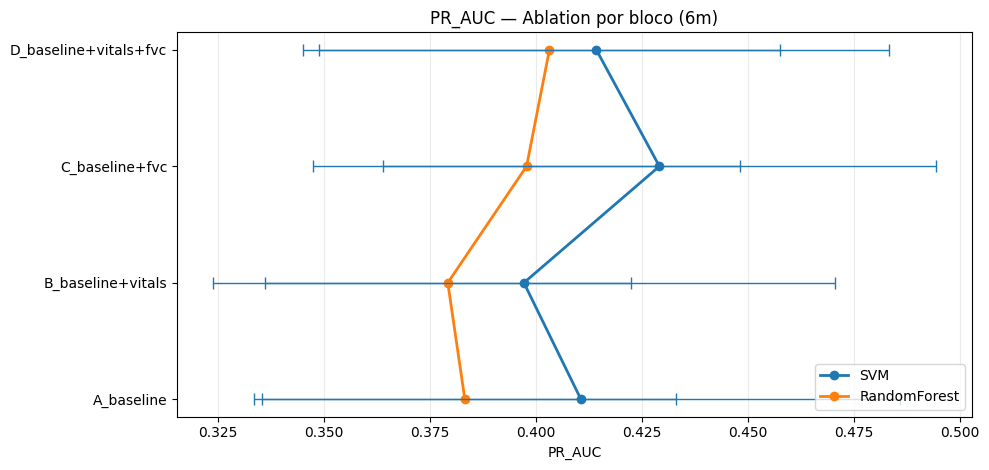

In [24]:
import numpy as np
import matplotlib.pyplot as plt

BLOCK_ORDER = ["A_baseline", "B_baseline+vitals", "C_baseline+fvc", "D_baseline+vitals+fvc"]

def dumbbell_plot(df, metric_mean, metric_std, horizon, outfile=None):
    # df: ablation_results filtrado por horizon e model
    plt.figure(figsize=(10, 4.8))

    for model_name in ["SVM", "RandomForest"]:
        d = df[(df["horizon"] == horizon) & (df["model"] == model_name)].copy()
        d["feature_block"] = pd.Categorical(d["feature_block"], categories=BLOCK_ORDER, ordered=True)
        d = d.sort_values("feature_block")

        y = np.arange(len(BLOCK_ORDER))
        x = d.set_index("feature_block").loc[BLOCK_ORDER, metric_mean].to_numpy()
        e = d.set_index("feature_block").loc[BLOCK_ORDER, metric_std].to_numpy()

        # linhas entre pontos
        plt.plot(x, y, marker="o", linewidth=2, label=model_name)
        # erro
        plt.errorbar(x, y, xerr=e, fmt="none", capsize=4, linewidth=1)

    plt.yticks(np.arange(len(BLOCK_ORDER)), BLOCK_ORDER)
    plt.xlabel(metric_mean.replace("_mean",""))
    plt.title(f"{metric_mean.replace('_mean','')} — Ablation por bloco ({horizon})")
    plt.grid(True, axis="x", alpha=0.25)
    plt.legend(loc="lower right")
    plt.tight_layout()

    if outfile:
        plt.savefig(outfile, dpi=300)
        print("Guardado:", outfile)
    plt.show()

# PR-AUC
dumbbell_plot(ablation_results, "PR_AUC_mean", "PR_AUC_std", "3m",
              outfile=os.path.join(OUT_FIGURES, "step5_1_ablation_dumbbell_pr_auc_3m.png"))
dumbbell_plot(ablation_results, "PR_AUC_mean", "PR_AUC_std", "6m",
              outfile=os.path.join(OUT_FIGURES, "step5_1_ablation_dumbbell_pr_auc_6m.png"))


Guardado: ..\04_outputs\figures\step5_1_ablation_dumbbell_f2_3m.png


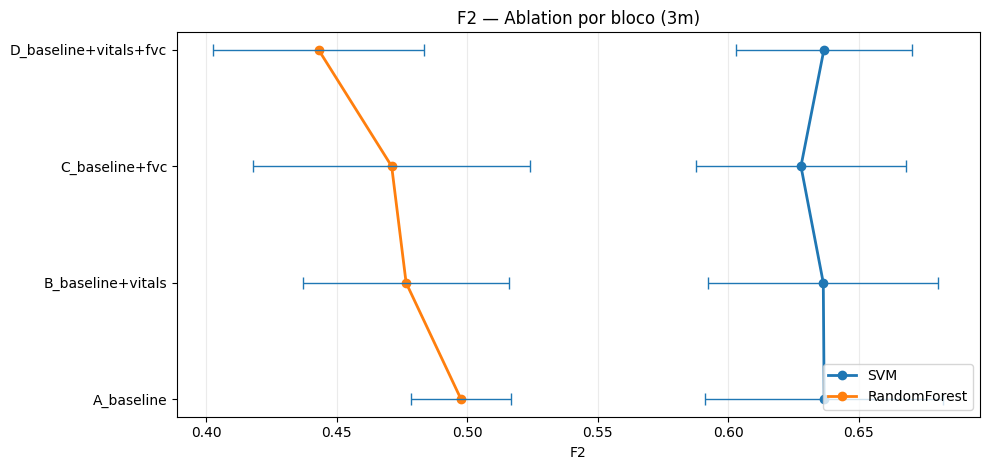

Guardado: ..\04_outputs\figures\step5_1_ablation_dumbbell_f2_6m.png


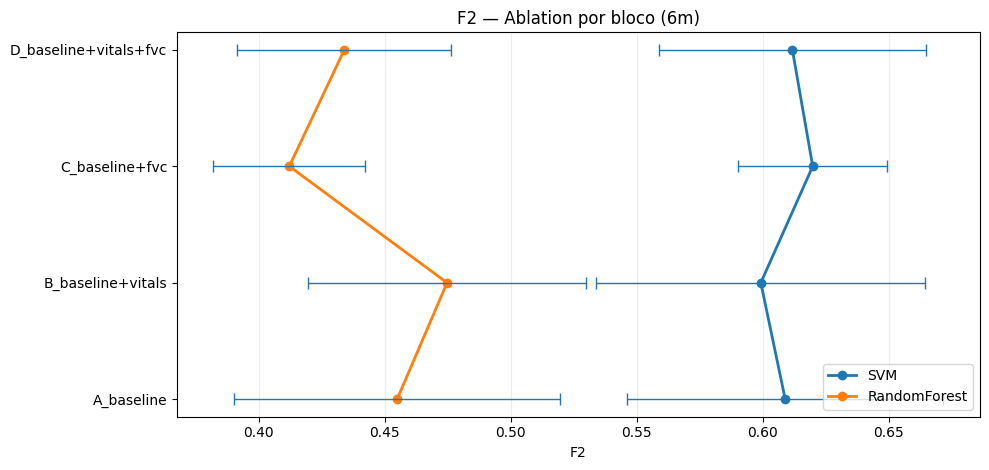

In [25]:
# F2
dumbbell_plot(ablation_results, "F2_mean", "F2_std", "3m",
              outfile=os.path.join(OUT_FIGURES, "step5_1_ablation_dumbbell_f2_3m.png"))
dumbbell_plot(ablation_results, "F2_mean", "F2_std", "6m",
              outfile=os.path.join(OUT_FIGURES, "step5_1_ablation_dumbbell_f2_6m.png"))


Guardado: ..\04_outputs\figures\step5_1_ablation_heatmap_pr_auc_3m.png


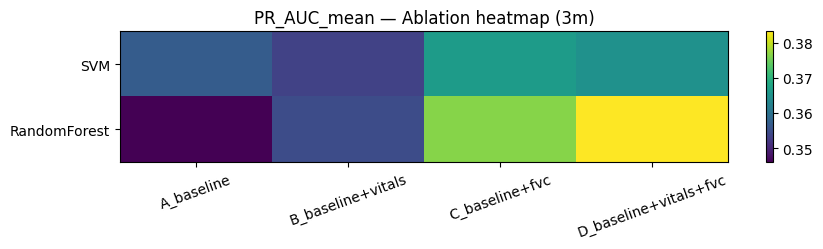

Guardado: ..\04_outputs\figures\step5_1_ablation_heatmap_pr_auc_6m.png


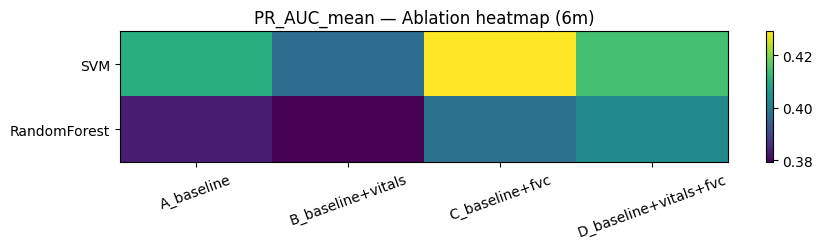

In [26]:
import matplotlib.pyplot as plt

def heatmap_ablation(df, horizon, metric="PR_AUC_mean", outfile=None):
    d = df[df["horizon"] == horizon].copy()
    d = d[d["model"].isin(["SVM","RandomForest"])]
    d["feature_block"] = pd.Categorical(d["feature_block"], categories=BLOCK_ORDER, ordered=True)

    pivot = d.pivot_table(index="model", columns="feature_block", values=metric, aggfunc="mean").loc[["SVM","RandomForest"], BLOCK_ORDER]

    plt.figure(figsize=(9, 2.6))
    plt.imshow(pivot.values, aspect="auto")
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=20)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.title(f"{metric} — Ablation heatmap ({horizon})")
    plt.colorbar()
    plt.tight_layout()

    if outfile:
        plt.savefig(outfile, dpi=300)
        print("Guardado:", outfile)
    plt.show()

heatmap_ablation(ablation_results, "3m", metric="PR_AUC_mean",
                 outfile=os.path.join(OUT_FIGURES, "step5_1_ablation_heatmap_pr_auc_3m.png"))
heatmap_ablation(ablation_results, "6m", metric="PR_AUC_mean",
                 outfile=os.path.join(OUT_FIGURES, "step5_1_ablation_heatmap_pr_auc_6m.png"))


# Step 5 — Extra: Logistic Regression (baseline interpretável)

## 🎯 Objetivo
Adicionar Logistic Regression como baseline interpretável mantendo o mesmo protocolo:
- GroupKFold subject-wise
- rapid = top 30% piores slopes (por fold)
- threshold otimizado por fold para maximizar F2

Este bloco não altera resultados anteriores (KNN/DT/RF/SVM); gera um output separado.

In [27]:
from sklearn.linear_model import LogisticRegression

def evaluate_logreg(X, slope, groups, horizon_name,
                    preproc_scaled,
                    top_frac=0.30, n_splits=5, beta=2, thr_grid=None, random_state=42):

    gkf = GroupKFold(n_splits=n_splits)

    pipe = Pipeline(steps=[
        ("prep", preproc_scaled),
        ("clf", LogisticRegression(
            max_iter=2000,
            solver="liblinear",
            class_weight="balanced",
            random_state=random_state
        ))
    ])

    pr_list, f1_list, f2_list = [], [], []
    tn_list, fp_list, fn_list, tp_list = [], [], [], []
    thr_list = []

    for fold, (tr, te) in enumerate(gkf.split(X, groups=groups), start=1):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        slope_tr, slope_te = slope.iloc[tr], slope.iloc[te]

        thr_label = np.nanquantile(slope_tr.dropna(), top_frac)
        ytr = (slope_tr <= thr_label).astype(int)
        yte = (slope_te <= thr_label).astype(int)

        pipe.fit(Xtr, ytr)

        proba_tr = pipe.predict_proba(Xtr)[:, 1]
        thr_decision, _ = pick_threshold_max_fbeta(ytr.to_numpy(), proba_tr, beta=beta, grid=thr_grid)
        thr_list.append(thr_decision)

        proba_te = pipe.predict_proba(Xte)[:, 1]
        yhat = (proba_te >= thr_decision).astype(int)

        pr_list.append(average_precision_score(yte, proba_te))
        f1_list.append(f1_score(yte, yhat, zero_division=0))
        f2_list.append(fbeta_score(yte, yhat, beta=beta, zero_division=0))

        tn, fp, fn, tp = confusion_matrix(yte, yhat, labels=[0,1]).ravel()
        tn_list.append(tn); fp_list.append(fp); fn_list.append(fn); tp_list.append(tp)

    return pd.DataFrame([{
        "horizon": horizon_name,
        "model": "LogReg_balanced",
        "PR_AUC_mean": float(np.mean(pr_list)),
        "PR_AUC_std": float(np.std(pr_list)),
        "F1_mean": float(np.mean(f1_list)),
        "F1_std": float(np.std(f1_list)),
        f"F{beta}_mean": float(np.mean(f2_list)),
        f"F{beta}_std": float(np.std(f2_list)),
        "TN_mean": float(np.mean(tn_list)),
        "FP_mean": float(np.mean(fp_list)),
        "FN_mean": float(np.mean(fn_list)),
        "TP_mean": float(np.mean(tp_list)),
        "thr_decision_mean": float(np.mean(thr_list)),
        "thr_decision_std": float(np.std(thr_list)),
    }])
    


In [28]:
lr3 = evaluate_logreg(X3, slope3, g3, "3m", preproc_scaled_3, top_frac=0.30, n_splits=5, beta=2)
lr6 = evaluate_logreg(X6, slope6, g6, "6m", preproc_scaled_6, top_frac=0.30, n_splits=5, beta=2)

lr_results = pd.concat([lr3, lr6], ignore_index=True)

out = os.path.join(OUT_TABLES, "step5_logreg_results.csv")
lr_results.to_csv(out, index=False)

print("Guardado:", out)
lr_results

Guardado: ..\04_outputs\tables\step5_logreg_results.csv


,horizon,model,PR_AUC_mean,PR_AUC_std,F1_mean,F1_std,F2_mean,F2_std,TN_mean,FP_mean,FN_mean,TP_mean,thr_decision_mean,thr_decision_std
0,3m,LogReg_balanced,0.371134,0.035408,0.465676,0.022181,0.672487,0.026057,22.4,313.2,6.2,139.6,0.3,0.031623
1,6m,LogReg_balanced,0.387320,0.071758,0.467122,0.053353,0.663036,0.045552,25.6,169.4,6.0,77.4,0.3,0.044721
